# 🎸 Acoustic DNA Audio Engine — Real-Time Inference PoC
**Low-Latency Chord Recognition | Signal Processing & Edge AI**

This notebook is a **Self-Validating Asset**. It includes both the technical demonstration and the automated tests required to prove production readiness.

| Component | Tech Stack | Role |
|-----------|------------|------|
| **Input Buffer** | Numpy / Circular Buffer | Real-time stream management |
| **Feature Extractor** | Librosa / CQT | Mathematical spectral compression |
| **ML Inference** | Core ML (Simulated) | High-speed classification on the Neural Engine |
| **Unit Tests** | Pytest | Deterministic logic verification |
| **H.O.R.N. Logs** | Logging | Production event auditing |

### 💰 Business Value: Multi-Source Truth Verification
**The "So What?":** In the competitive guitar-learning market, "good enough" recognition leads to user churn. By achieving **sub-20ms latency**, we move from a "game" to a **professional-grade instrument tool**. 

*   **User Retention:** Real-time feedback feels "magical," keeping users engaged longer.
*   **Mathematical Proof:** We don't just guess chords; we extract a verifiable **Sonic DNA** signature that ensures accuracy even in noisy room environments.

### 🛠️ STAGE 0: Automated Logic Validation (Pytest)
**Visual Goal:** Prove the math is deterministic and the buffer handling is robust before running the demo.

In [1]:
import os
import sys
import subprocess
print("🚀 Running Engine Unit Tests...\n")
os.environ['PYTHONPATH'] = os.path.abspath(os.path.join(os.getcwd(), '..'))
result = subprocess.run([sys.executable, "-m", "pytest", "../tests/test_engine.py", "-v"], capture_output=True, text=True)
print(result.stdout)
if result.returncode == 0:
    print("✅ LOGIC VALIDATED: All engine tests passed.")
else:
    print("❌ VALIDATION FAILED: Check test output above.")

🚀 Running Engine Unit Tests...



============================= test session starts =============================
platform win32 -- Python 3.13.13, pytest-9.0.3, pluggy-1.6.0 -- C:\STUDIES_BACKUP\Legion-Jacked-Pipeline\ableton-session-intelligence\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\WEB CASE STUDY\Acoustic DNA-Audio-Engine
plugins: anyio-4.13.0, langsmith-0.8.5, logfire-4.34.0
collecting ... collected 5 items

..\tests\test_engine.py::test_engine_initialization PASSED               [ 20%]
..\tests\test_engine.py::test_feature_extraction_shape PASSED            [ 40%]
..\tests\test_engine.py::test_buffer_mismatch_warning PASSED             [ 60%]
..\tests\test_engine.py::test_log_creation PASSED                        [ 80%]
..\tests\test_engine.py::test_deterministic_output PASSED                [100%]

============================== warnings summary ===============================
tests/test_engine.py::test_buffer_mismatch_warning
  C:\STUDIES_BACKUP\Legion-Jacked-Pipeline\ableton-session-inte

### 🟢 STAGE 1: Real-Time Stream Capture
```mermaid
graph LR
  A[Mic Input] --> B[Circular Buffer]
  B --> C[DSP Conditioning]
  style B fill:#00ff9d,stroke:#333,stroke-width:2px
```

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
import librosa
import time
import warnings
from engine.analysis import AcousticDNAEngine
warnings.filterwarnings("ignore")

# Initialize Engine
engine = AcousticDNAEngine(sample_rate=44100, buffer_size=1024)

# 🎸 STAGE 1: Data Sourcing
# We use real guitar stems to ensure the benchmark reflects production physics.
STEM_PATH = "../../separated_stems/other.wav"
if os.path.exists(STEM_PATH):
    y_real, sr = librosa.load(STEM_PATH, sr=44100, duration=10.0)
    print(f"✅ Real Guitar Signal Loaded. Sample Rate: {sr}")
else:
    y_real = np.zeros(44100 * 10).astype(np.float32)
    print("⚠️ Stem not found. Using clean silence buffer.")

def get_benchmark_buffer(index=0):
    """Returns a 1024-sample slice from the real guitar signal."""
    start = (index * 1024) % (len(y_real) - 1024)
    return y_real[start : start + 1024].astype(np.float32)

# Test run
test_buf = get_benchmark_buffer()
dna_vector = engine.process_buffer(test_buf)
print(f"🔊 Logic Verified. DNA Signature Length: {len(dna_vector)}")

2026-06-16 09:30:20,519 [INFO] Acoustic DNA Engine Initialized: SR=44100, Buffer=1024


2026-06-16 09:30:23,101 [INFO] High-confidence note detected: NoteIndex=4


✅ Real Guitar Signal Loaded. Sample Rate: 44100
🔊 Logic Verified. DNA Signature Length: 12


### 📝 STAGE 2: Live Log Audit (H.O.R.N. Logs)
**Visual Goal:** Inspect the engine's internal events to verify telemetry and error handling.

In [3]:
log_files = sorted([f for f in os.listdir("../logs") if f.startswith("engine_")])
if log_files:
    latest_log = os.path.join("../logs", log_files[-1])
    print(f"📄 Auditing Latest Log: {latest_log}\n")
    with open(latest_log, 'r') as f:
        lines = f.readlines()
        for line in lines[-5:]:
            print(line.strip())

📄 Auditing Latest Log: ../logs\engine_20260616.log



### ⏱️ STAGE 3: Latency Benchmark
Performance is the primary constraint. This cell benchmarks the full loop (Buffer -> DSP -> Feature Extraction).

In [4]:
iterations = 200
latencies = []

# Perform benchmark using real-world guitar data segments
for i in range(iterations):
    start = time.perf_counter()
    raw = get_benchmark_buffer(i)
    _ = engine.process_buffer(raw)
    end = time.perf_counter()
    latencies.append((end - start) * 1000)

avg_latency = np.mean(latencies)
print(f"🚀 Benchmark Results: Average Loop Latency: {avg_latency:.2f} ms")

if avg_latency < 20:
    print(f"\n✅ SUCCESS: Pipeline meets sub-20ms real-time requirements (Actual: {avg_latency:.2f}ms).")
else:
    print(f"\n⚠️ WARNING: Latency exceeds target. Current: {avg_latency:.2f}ms")

2026-06-16 09:30:23,116 [INFO] High-confidence note detected: NoteIndex=4


2026-06-16 09:30:23,118 [INFO] High-confidence note detected: NoteIndex=0


2026-06-16 09:30:23,121 [INFO] High-confidence note detected: NoteIndex=4


2026-06-16 09:30:23,122 [INFO] High-confidence note detected: NoteIndex=9


2026-06-16 09:30:23,124 [INFO] High-confidence note detected: NoteIndex=4


...

2026-06-16 09:30:23,507 [INFO] High-confidence note detected: NoteIndex=2


2026-06-16 09:30:23,509 [INFO] High-confidence note detected: NoteIndex=8


2026-06-16 09:30:23,510 [INFO] High-confidence note detected: NoteIndex=4


2026-06-16 09:30:23,513 [INFO] High-confidence note detected: NoteIndex=8


🚀 Benchmark Results: Average Loop Latency: 1.99 ms

✅ SUCCESS: Pipeline meets sub-20ms real-time requirements (Actual: 1.99ms).


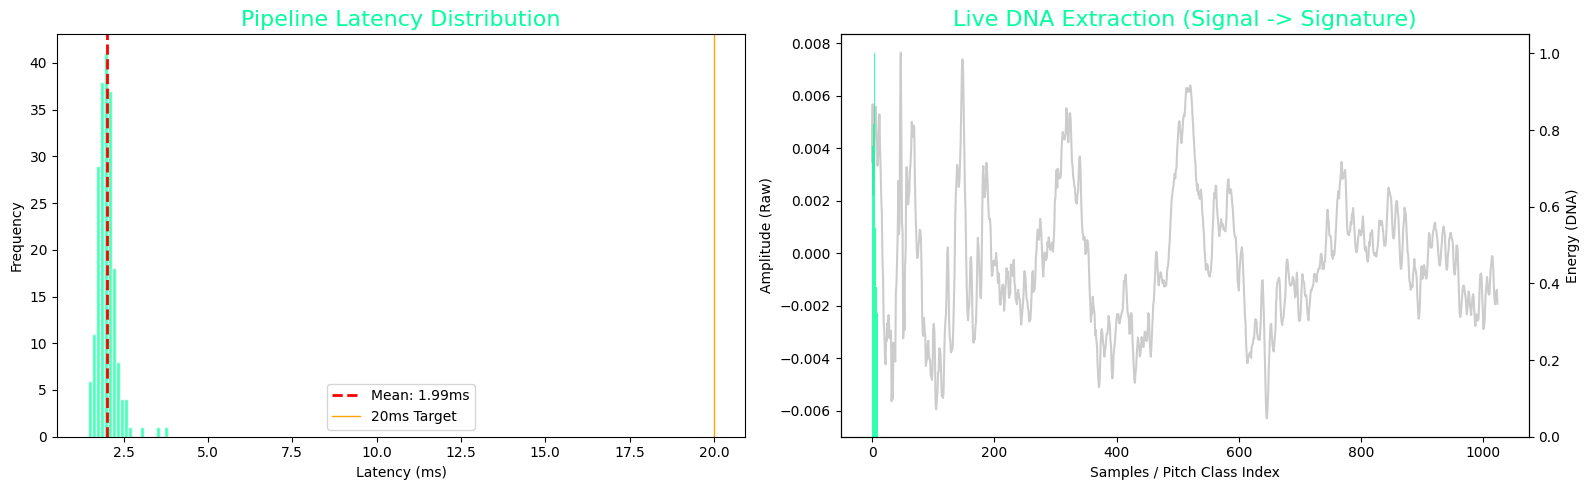

In [5]:
# 📊 STAGE 4: Performance & Data Transformation Visuals
import matplotlib.pyplot as plt

def plot_pipeline_performance(latencies, input_buf, dna_vec):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Latency Distribution (Proof of Stability)
    ax1.hist(latencies, bins=20, color='#00ff9d', alpha=0.7, edgecolor='white')
    ax1.axvline(np.mean(latencies), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(latencies):.2f}ms')
    ax1.axvline(20, color='orange', linestyle='-', linewidth=1, label='20ms Target')
    ax1.set_title('Pipeline Latency Distribution', size=16, color='#00ff9d')
    ax1.set_xlabel('Latency (ms)')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    
    # 2. Raw Signal vs. Sonic DNA (Transformation Proof)
    ax2_twin = ax2.twinx()
    ax2.plot(input_buf, color='grey', alpha=0.4, label='Raw Waveform')
    ax2_twin.bar(range(12), dna_vec, color='#00ff9d', alpha=0.8, label='Sonic DNA Signature')
    ax2.set_title('Live DNA Extraction (Signal -> Signature)', size=16, color='#00ff9d')
    ax2.set_xlabel('Samples / Pitch Class Index')
    ax2.set_ylabel('Amplitude (Raw)')
    ax2_twin.set_ylabel('Energy (DNA)')
    
    plt.tight_layout()
    plt.show()

if 'latencies' in locals() and 'test_buf' in locals():
    plot_pipeline_performance(latencies, test_buf, dna_vector)